In [19]:
from pathlib import Path

import pandas as pd
import structlog
from tqdm import tqdm

from hilary.apriori import Apriori
from hilary.inference import HILARy
from hilary.utils import create_classes, pairwise_evaluation

from hilary_old.apriori import Apriori as Apriori_old
from hilary_old.utils import create_classes as create_classes_old
from hilary_old.inference import HILARy as HILARy_old

import matplotlib.pyplot as plt
import seaborn as sns
log = structlog.get_logger(__name__)
file_path = "data_for_tests"

thresholds_dict={
    "partis_single_20":{"precision_cdr":0.995,"sensitivity_full":0.89, "precision_full":0.995},
    "partis_single_05":{"precision_cdr":0.965,"sensitivity_cdr":0.925,"sensitivity_full":0.985, "precision_full":0.97},# downgrade of sensitivity_full 0.975
    "nat_15":{"precision_cdr":0.995,"precision_full":0.995,"sensitivity_full":0.975},
    "nat_24":{"precision_cdr":0.995,"precision_full":0.99,"sensitivity_full":0.975},
    "nat_39":{"precision_cdr":0.995,"sensitivity_cdr":0.96,"precision_full":0.995,"sensitivity_full":0.985},
    "naive_human":{"precision":0.995},
    "naive_mouse":{"precision":0.995}}

hilary_pars={'precision':1,'sensitivity':0.95,'null_model':'jl'}
old_pars={'precision':1,'sensitivity':0.95,'null_model':'l'}

# here some code to infer clonal families.
def infer_hilary(dataframe_processed,precision,sensitivity,null_model,model='human_B_heavy',crude=0.1):
    apriori = Apriori(silent=False, threads=-1, precision=precision, sensitivity=sensitivity,model=model,infer_cdf=False,null_model=null_model)
    df = apriori.preprocess(df=dataframe_processed, df_light=None)
    df['ground_truth']=dataframe_processed['ground_truth'].astype('str')
    apriori.classes = create_classes(df)
    apriori.get_histograms(df)
    apriori.get_parameters()
    hilary = HILARy(apriori, df=df)
    df1=hilary.compute_crude_method_clusters(df,normalized_threshold=crude)
    dataframe_cdr3 = hilary.compute_prec_sens_clusters(df=df)
    df_out=dataframe_cdr3.copy()
    hilary.get_xy_thresholds(df=dataframe_cdr3)
    hilary.classes["xy_threshold"] = hilary.classes["xy_threshold"]
    df_full=hilary.infer(df=dataframe_cdr3)
    return df1,apriori,df_full
from hilary_old.apriori import Apriori as Apriori_old
from hilary_old.utils import create_classes as create_classes_old
from hilary_old.inference import HILARy as HILARy_old
def infer_hilary_old(dataframe_processed,species='human',fast=False,old=False,precision=0.999,sensitivity=0.95,crude=0.15):
    df=dataframe_processed.copy()
    apriori = Apriori_old(silent=False, threads=-1, precision=precision, sensitivity=sensitivity)
    df = apriori.preprocess(df=dataframe_processed, df_kappa=None)
    df['ground_truth']=dataframe_processed['ground_truth'].astype('str')
    apriori.classes = create_classes_old(df)
    apriori.get_histograms(df)
    apriori.get_parameters()
    apriori.get_thresholds()
    hilary = HILARy_old(apriori, df=df)
    df1=hilary.compute_crude_method_clusters(df,normalized_threshold=crude)
    dataframe_cdr3 = hilary.compute_prec_sens_clusters(df=df1)
    if fast: return dataframe_cdr3,apriori,0
    df_out=dataframe_cdr3.copy()
    hilary.get_xy_thresholds(df=dataframe_cdr3)
    hilary.classes["xy_threshold"] = hilary.classes["xy_threshold"]
    df_full=hilary.infer(df=dataframe_cdr3)
    return df_out,apriori,df_full

In [2]:
from sklearn.metrics import adjusted_mutual_info_score,homogeneity_completeness_v_measure

In [20]:
dfs=[]
names=[]
sens_threshold=[]
for length in [15, 24, 39]:
        dataframe = pd.read_csv(
            file_path + f"/families1_1e4_ppost326651_mut326713_cdr3l{length}.csv.gz",
            compression="gzip")
        dataframe = dataframe.rename(
            columns={
                "alt_sequence_alignment_bis": "alt_sequence_alignment",
                "alt_germline_alignment_bis": "alt_germline_alignment",
                "V_GENE": "v_gene",
                "J_GENE": "j_gene",
                "CDR3_LENGTH": "cdr3_length",
                "CDR3": "cdr3",
                "FAMILY": "ground_truth"})
        dataframe["sequence_id"] = dataframe.index.astype("str")
        dfs.append(dataframe)
        names.append(f"nat_{length}")
        sens_threshold.append(0.95)

for mut in ["05","20"]:
        dataframe = pd.read_csv(
            file_path + f"/partis_{mut}/single_chain/igh.csv.gz",
            compression="gzip",
        )
        dataframe = dataframe.rename(
            columns={
                "v_gl_seq": "v_germline_alignment",
                "v_qr_seqs": "v_sequence_alignment",
                "j_gl_seq": "j_germline_alignment",
                "j_qr_seqs": "j_sequence_alignment",
                "clone_id": "ground_truth"})
        dataframe["sequence_id"] = dataframe.index.astype("str")
        dfs.append(dataframe)
        names.append(f"partis_{mut}")
        sens_threshold.append(1)

In [ ]:
results,results_old=[],[]
for dataframe,name,sens_thresh in zip(dfs,names,sens_threshold):
        df_out,apriori,df_full=infer_hilary(dataframe,precision=hilary_pars['precision'],sensitivity=sens_thresh,null_model=hilary_pars['null_model'],crude=0.1)
        precision_crude, sensitivity_crude = pairwise_evaluation(df=df_out, partition="crude_method_family")
        precision_cdr3, sensitivity_cdr3 = pairwise_evaluation(df=df_full, partition="precise_cluster")
        precision_full, sensitivity_full = pairwise_evaluation(df=df_full, partition="clone_id")
        homogeneity_crude,completeness_crude,vmeasure_crude=homogeneity_completeness_v_measure(df_out['ground_truth'],df_out['crude_method_family'])
        homogeneity_cdr3,completeness_cdr3,vmeasure_cdr3=homogeneity_completeness_v_measure(df_full['ground_truth'],df_full['precise_cluster'])
        homogeneity_full,completeness_full,vmeasure_full=homogeneity_completeness_v_measure(df_full['ground_truth'],df_full['clone_id'])
        results.append([name,precision_cdr3,sensitivity_cdr3,precision_full,sensitivity_full,
                        precision_crude, sensitivity_crude,homogeneity_crude,completeness_crude,vmeasure_crude,
                        homogeneity_cdr3,completeness_cdr3,vmeasure_cdr3,homogeneity_full,completeness_full,vmeasure_full])
        df_out,apriori,df_full=infer_hilary_old(dataframe,precision=old_pars['precision'],sensitivity=sens_thresh,crude=0.15)
        precision_crude, sensitivity_crude = pairwise_evaluation(df=df_out, partition="crude_method_family")
        precision_cdr3, sensitivity_cdr3 = pairwise_evaluation(df=df_full, partition="precise_cluster")
        precision_full, sensitivity_full = pairwise_evaluation(df=df_full, partition="clone_id")
        homogeneity_crude,completeness_crude,vmeasure_crude=homogeneity_completeness_v_measure(df_out['ground_truth'],df_out['crude_method_family'])
        homogeneity_cdr3,completeness_cdr3,vmeasure_cdr3=homogeneity_completeness_v_measure(df_full['ground_truth'],df_full['precise_cluster'])
        homogeneity_full,completeness_full,vmeasure_full=homogeneity_completeness_v_measure(df_full['ground_truth'],df_full['clone_id'])   
        results_old.append([name,precision_cdr3,sensitivity_cdr3,precision_full,sensitivity_full,
                        precision_crude, sensitivity_crude,homogeneity_crude,completeness_crude,vmeasure_crude,
                        homogeneity_cdr3,completeness_cdr3,vmeasure_cdr3,homogeneity_full,completeness_full,vmeasure_full])

 38%|███▊      | 60/156 [00:00<00:00, 599.42it/s]

100%|██████████| 156/156 [00:00<00:00, 745.76it/s]

2025-05-21 08:41:55 [debug    ] Computing CDR3 hamming distances within all large VJl classes.



100%|██████████| 120/120 [00:01<00:00, 86.81it/s]

2025-05-21 08:41:57 [debug    ] Computing prevalence and mean distance for all classes


...


0it [00:00, ?it/s]
100%|██████████| 3013/3013 [00:02<00:00, 1042.84it/s]


2025-05-21 08:43:22 [debug    ] Computing CDR3 hamming distances within all large VJl classes.


100%|██████████| 29/29 [00:00<00:00, 145.61it/s]

2025-05-21 08:43:33 [info     ] Using crude method with a normalized threshold of 0.15



 59%|█████▉    | 1797/3042 [00:05<00:04, 308.40it/s]

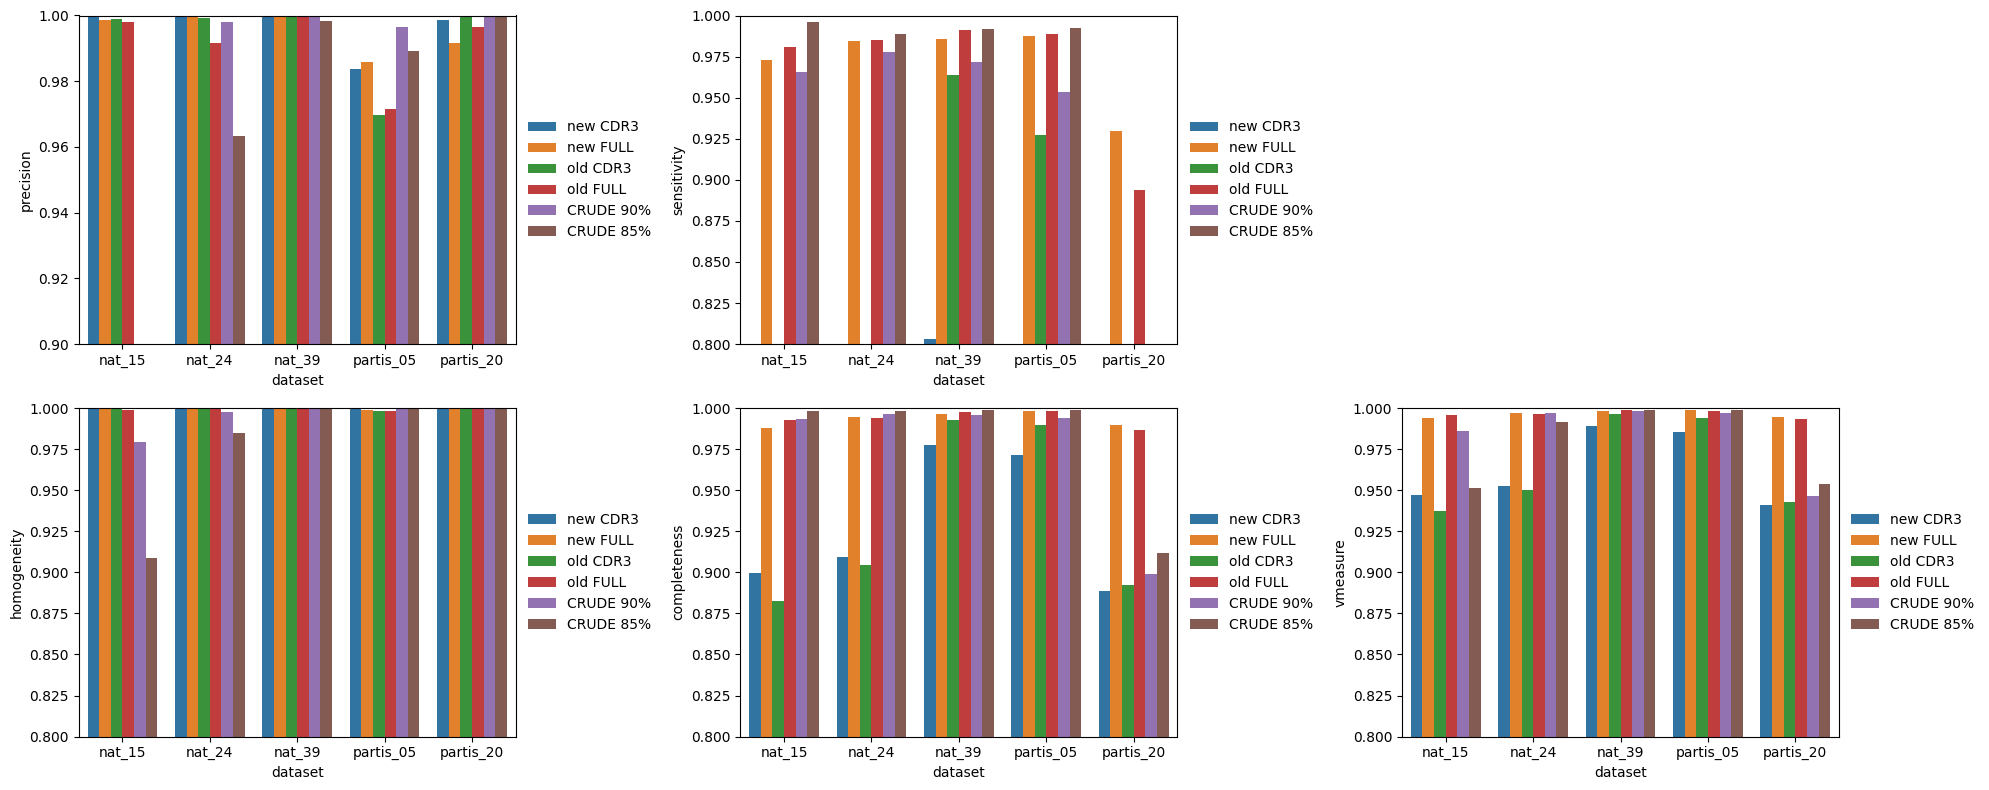

In [18]:
columns=['dataset','precision_cdr3','sensitivity_cdr3','precision_full','sensitivity_full','precision_crude',
         'sensitivity_crude','homogeneity_crude','completeness_crude','vmeasure_crude','homogeneity_cdr3','completeness_cdr3',
         'vmeasure_cdr3','homogeneity_full','completeness_full','vmeasure_full']

dfnew=pd.DataFrame(results,columns=columns)
dfold=pd.DataFrame(results_old,columns=columns)

df0=dfnew[['dataset','precision_cdr3','sensitivity_cdr3','homogeneity_cdr3','completeness_cdr3','vmeasure_cdr3']]
df0.columns=['dataset','precision','sensitivity','homogeneity','completeness','vmeasure']
df0['kind']='new CDR3'

df1=dfnew[['dataset','precision_full','sensitivity_full','homogeneity_full','completeness_full','vmeasure_full']]
df1.columns=['dataset','precision','sensitivity','homogeneity','completeness','vmeasure']
df1['kind']='new FULL'

df2=dfold[['dataset','precision_cdr3','sensitivity_cdr3','homogeneity_cdr3','completeness_cdr3','vmeasure_cdr3']]
df2.columns=['dataset','precision','sensitivity','homogeneity','completeness','vmeasure']
df2['kind']='old CDR3'

df3=dfold[['dataset','precision_full','sensitivity_full','homogeneity_full','completeness_full','vmeasure_full']]
df3.columns=['dataset','precision','sensitivity','homogeneity','completeness','vmeasure']
df3['kind']='old FULL'

df4=dfnew[['dataset','precision_crude','sensitivity_crude','homogeneity_crude','completeness_crude','vmeasure_crude']]
df4.columns=['dataset','precision','sensitivity','homogeneity','completeness','vmeasure']
df4['kind']='CRUDE 90%'

df5=dfold[['dataset','precision_crude','sensitivity_crude','homogeneity_crude','completeness_crude','vmeasure_crude']]
df5.columns=['dataset','precision','sensitivity','homogeneity','completeness','vmeasure']
df5['kind']='CRUDE 85%'

df=pd.concat([df0,df1,df2,df3,df4,df5])
plt.figure(figsize=(20,8))
plt.subplot(231)
sns.barplot(data=df,x='dataset',y='precision',hue='kind')
plt.ylim([0.9,1])
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5),frameon=False)
plt.subplot(232)
sns.barplot(data=df,x='dataset',y='sensitivity',hue='kind')
plt.ylim([0.8,1])
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5),frameon=False)
plt.subplot(234)
sns.barplot(data=df,x='dataset',y='homogeneity',hue='kind')
plt.ylim([.8,1])
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5),frameon=False)
plt.subplot(235)
sns.barplot(data=df,x='dataset',y='completeness',hue='kind')
plt.ylim([.8,1])
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5),frameon=False)
plt.subplot(236)
sns.barplot(data=df,x='dataset',y='vmeasure',hue='kind')
plt.ylim([.8,1])
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5),frameon=False)
plt.tight_layout()
plt.show()


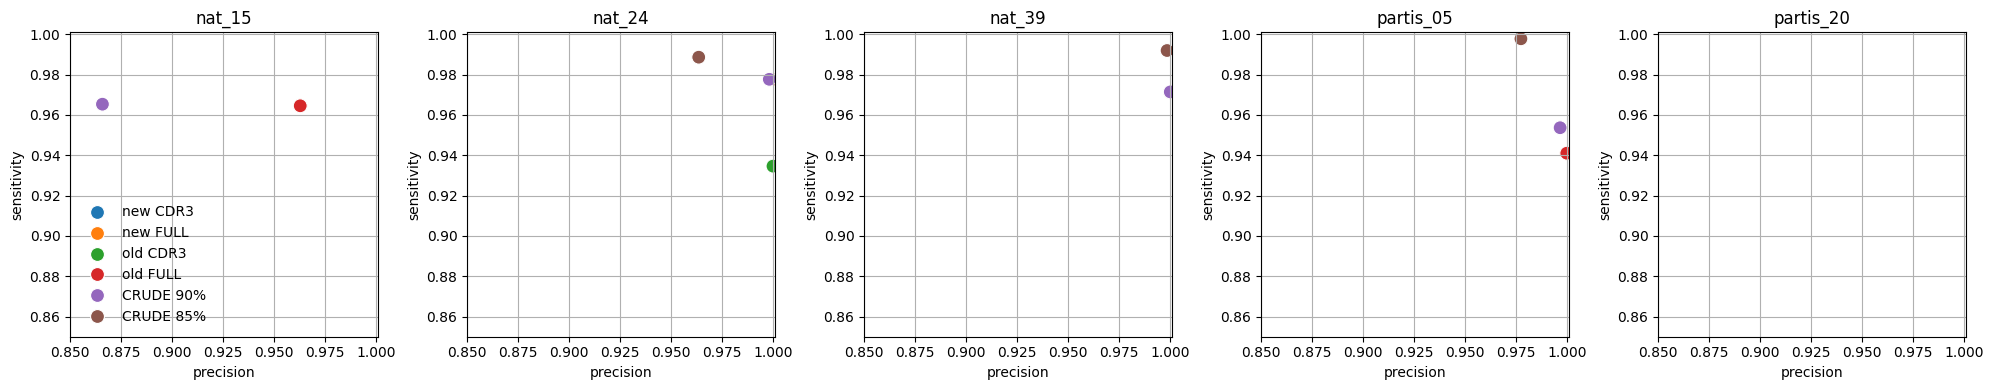

In [6]:
plt.figure(figsize=(20,4))
for i,d in enumerate(df['dataset'].unique()):
    ax=plt.subplot(1,5,1+i)
    plt.title(d)
    sns.scatterplot(data=df[df['dataset']==d],x='precision',y='sensitivity',hue='kind',s=100)
    plt.xlim([0.85,1.001])
    if i!=4:
        plt.ylim([0.85,1.001])
    else:
        plt.ylim([0.85,1.001])

    if i!=0:
        ax.get_legend().remove()
    else:
        plt.legend(frameon=False,loc='lower left')
    plt.grid()
plt.tight_layout()
plt.show()

In [ ]:



dfnew=pd.DataFrame(results,columns=["dataset","precision_cdr3","sensitivity_cdr3","precision_full","sensitivity_full","precision_crude","sensitivity_crude"])
dfold=pd.DataFrame(results_old,columns=["dataset","precision_cdr3","sensitivity_cdr3","precision_full","sensitivity_full","precision_crude","sensitivity_crude"])
df2['kind']='old'
df=pd.concat([df1,df2])
plt.figure(figsize=(10,6))
plt.subplot(221)
sns.barplot(data=df,x='dataset',y='precision_cdr3',hue='kind')
plt.ylim([0.97,1])
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5),frameon=False)
plt.subplot(222)
sns.barplot(data=df,x='dataset',y='precision_full',hue='kind')
plt.ylim([0.97,1])
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5),frameon=False)

plt.subplot(223)
sns.barplot(data=df,x='dataset',y='sensitivity_cdr3',hue='kind')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5),frameon=False)

plt.ylim([0.,1])
plt.subplot(224)
sns.barplot(data=df,x='dataset',y='sensitivity_full',hue='kind')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5),frameon=False)

plt.ylim([0.85,1])
plt.tight_layout()